-0.5122140239833405	-19.463609589946135
-0.5085085085085086


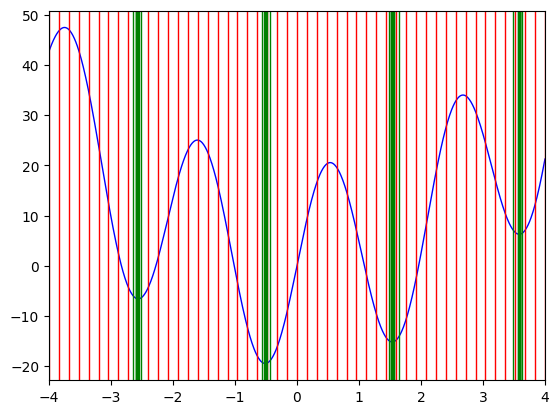

In [34]:
import numpy as np
import matplotlib.pyplot as plt 

t0 = -4
tf =  4
x = np.linspace(t0,tf,1000)
def f(x):
    return 20*np.sin(3*x) + 2*x**2 

plt.plot(x,f(x),'b-',lw=1)
plt.xlim(t0,tf)


def minima_finder (
        t0,
        tf,
        f,
        max_iter = 1000,
        n = 51,
        tol = 1e-12
    ):
    t_list = np.linspace(t0,tf,n)
    f_list = f(t_list)
    for t in t_list:
        plt.axvline(t,color='r',lw=1)
    minima_candidate = []
    if f_list[0] <= f_list[1]:
        minima_candidate.append(0)
    if f_list[n-1] <= f_list[n-2]:
        minima_candidate.append(n-1)
    for i in range(0,n-1):
        if f_list[i] <= f_list[i-1] and f_list[i] <= f_list[i+1]:
            minima_candidate.append(i)

    def golden_section(a, b):
        gr = (np.sqrt(5) - 1) / 2
        c = b - gr * (b - a)
        d = a + gr * (b - a)
        fc = f(c)
        fd = f(d)
        
        for i in range(max_iter):
            if abs(b - a) < tol:
                break
            plt.axvline(c, color='g', lw=1)
            plt.axvline(d, color='g', lw=1)
            
            if fc < fd:
                b = d
                d = c
                fd = fc
                c = b - gr * (b - a)
                fc = f(c)
            else:
                a = c
                c = d
                fc = fd
                d = a + gr * (b - a)
                fd = f(d)
        return (a + b) / 2
    
    best_t = None
    best_f = np.inf 
    t_candidate = -1 
    f_candidate = np.inf
    for midx in minima_candidate:
        if midx == 0:
            t_candidate = t_list[0]
        elif midx == n-1:
            t_candidate = t_list[n-1]  
        else:
            a = t_list[midx - 1]
            b = t_list[midx + 1]
            t_candidate = golden_section(a,b)
        f_candidate = f(t_candidate)
        if f_candidate < best_f:
            best_f = f_candidate
            best_t = t_candidate 
    if (abs(best_t - t0) < tol) or (abs(best_t - tf) < tol):
        print("MINIMA MIGHT BE OUTSIDE BOUNDS")
    return best_t

min_t= minima_finder(t0,tf,f)
print(f"{min_t}\t{f(min_t)}")
print(x[np.argmin(f(x))])
plt.show() 
            